In [2]:
# ------------------------------------------------------------
# Setup
# ------------------------------------------------------------
# Purpose: Import libraries and configure training environment.

# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/d/mohammedmorsy/ubuntu-tokenizer/ubuntu.model
/kaggle/input/d/mohammedmorsy/ubuntu-tokenizer/input_output_dataset.csv
/kaggle/input/d/mohammedmorsy/ubuntu-tokenizer/ubuntu.vocab
/kaggle/input/ubuntu-dialogues-corpus/full_text.txt
/kaggle/input/ubuntu-dialogues-corpus/cleaned_dialogues_corpus.csv


In [3]:
# ------------------------------------------------------------
# Tokenization
# ------------------------------------------------------------
# Purpose: Prepare subword tokenization and vocabulary.

!pip install sentencepiece --quiet
!pip install sacrebleu --quiet
!pip install torchdata --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.8/51.8 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 1.9 MB/s eta 0:00:00


In [71]:
# ------------------------------------------------------------
# Setup
# ------------------------------------------------------------
# Purpose: Import libraries and configure training environment.

import ast
import re
import math
import sentencepiece as spm #tokenizer
import torchdata
import sacrebleu #Evaluation metric
from dataclasses import dataclass
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import utils
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
seed = 7
torch.manual_seed(seed)
np.random.seed(seed)
pd.set_option('display.max_colwidth', None)

In [5]:
# ------------------------------------------------------------
# Processing
# ------------------------------------------------------------
# Purpose: Execute intermediate transformation steps.

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

# **<center>1. Sentence Piece Tokenizer Building</center>**
___

- The main advantage of a subword tokenizer is that it interpolates between word-based and character-based tokenization.
- Common words get a slot in the vocabulary, but the tokenizer can fall back to word pieces and individual characters for unknown words.

###  **Build the tokenizer**

- Use `<sep>` as a user_defined_symbol to concatenate dialogue turns, enabling the model to maintain the dialogue history for predicting the next turn

In [ ]:
# ------------------------------------------------------------
# Tokenization
# ------------------------------------------------------------
# Purpose: Prepare subword tokenization and vocabulary.

Vocab_size = 10000
spm.SentencePieceTrainer.train(f'--input=/kaggle/input/ubuntu-dialogues-corpus/full_text.txt --model_prefix=ubuntu --user_defined_symbols=<pad>,<sep> --vocab_size={Vocab_size}')

In [6]:
# ------------------------------------------------------------
# Data Loading
# ------------------------------------------------------------
# Purpose: Load cleaned dialogue data from Part 1.

sp = spm.SentencePieceProcessor()
sp.load('/kaggle/input/d/mohammedmorsy/ubuntu-tokenizer/ubuntu.model')
tokenizer_ids = sp.encode_as_ids
tokenizer_pieces = sp.encode_as_pieces
detokenizer_ids = sp.decode_ids
detokenizer_pieces = sp.decode_pieces

In [7]:
# ------------------------------------------------------------
# Tokenization
# ------------------------------------------------------------
# Purpose: Prepare subword tokenization and vocabulary.

detokenizer_ids([3, 4])

'<pad><sep>'

# **<center>2. Create Input-Output Pairs from Dialogues</center>**
___

1. Separate each dialogue into input and output sentences.
2. To achieve this, we use a `sliding window` of size 5. We begin with the first sentence as the input and the second as the output. Next, we concatenate the first and second sentences using the special token `4` to form the input, with the third sentence as the output. This process continues until the input consists of `up to 5 sentences`. Once the window size reaches 5, we shift the window by removing the first sentence and including the next one, ensuring that each input contains a maximum of 5 sentences. This step is repeated until we process the final set of six sentences, where the first five sentences form the input, and the last one serves as the output.
3. This process is designed to enable the model to `track` what’s happened in the conversation previously, and `generate` appropriate responses.

**Note**: I apply a sliding window approach in reverse, where the most recent turn comes first.

In [ ]:
# ------------------------------------------------------------
# Data Loading
# ------------------------------------------------------------
# Purpose: Load cleaned dialogue data from Part 1.

dialogues_corpus = pd.read_csv('/kaggle/input/ubuntu-dialogues-corpus/cleaned_dialogues_corpus.csv')

In [ ]:
# ------------------------------------------------------------
# Processing
# ------------------------------------------------------------
# Purpose: Execute intermediate transformation steps.

type(dialogues_corpus['dialogue_texts'][0])

In [ ]:
# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------
# Purpose: Evaluate model performance on validation data.

# Convert the string representations of lists back to actual lists
dialogues_corpus['dialogue_texts'] = dialogues_corpus['dialogue_texts'].apply(ast.literal_eval)

In [ ]:
# ------------------------------------------------------------
# Processing
# ------------------------------------------------------------
# Purpose: Execute intermediate transformation steps.

type(dialogues_corpus['dialogue_texts'][0])

In [ ]:
# ------------------------------------------------------------
# Tokenization
# ------------------------------------------------------------
# Purpose: Prepare subword tokenization and vocabulary.

def generate_input_output(df, tokenizer_ids, BOS, EOS, SEP, dialogue_texts, window=5):
    """
    Generates input-output pairs for a dataset using a sliding window approach.

    Parameters:
        df (pd.DataFrame): DataFrame containing dialogue data.
        tokenizer_ids (function): Function to tokenize text into IDs.
        BOS (list): Beginning of sequence token.
        EOS (list): End of sequence token.
        SEP (list): Separator token.
        dialogue_texts (str): Column name in the DataFrame containing dialogue texts.
        window (int): Size of the sliding window for context. Default is 5.

    Returns:
        list: A list of tuples containing input (list) and output (list).
    """
    input_output = []
    for _, row  in df.iterrows():
        data = row[dialogue_texts] # Access dialogue texts using the column name
        dialogue_inp_out = []
        
        for i in range(len(data) - 1):
            inp = tokenizer_ids(data[i])
            out = BOS + tokenizer_ids(data[i + 1]) + EOS
        
            if i >= window:
                # Handle cases where the context window is fully established
                if i == window:
                    previous_input = dialogue_inp_out[i-1][0]
                    l =len(dialogue_inp_out[i-window][0])
                    dial_inp = BOS + inp + SEP + previous_input[1:-l] + EOS
        
                else:
                    previous_input = dialogue_inp_out[i-1][0]
                    l =len(dialogue_inp_out[i-window-1][1])
                    dial_inp = BOS + inp + SEP + previous_input[1:-l] + EOS
                
                    
            elif dialogue_inp_out:
                # Build context from existing dialogue_inp_out
                previous_input = dialogue_inp_out[i-1][0][1:]
                
                dial_inp = BOS + inp + SEP + previous_input
        
            else:
               # First input without prior context
                dial_inp = BOS + inp + EOS
                
            dialogue_inp_out.append((dial_inp, out))
        input_output += dialogue_inp_out
        
    input_output_dataset = pd.DataFrame(input_output, columns=['input_tokens', 'output_tokens'])
    return input_output_dataset

In [45]:
# ------------------------------------------------------------
# Processing
# ------------------------------------------------------------
# Purpose: Execute intermediate transformation steps.

UNK, BOS, EOS, PAD, SEP = [0], [1], [2], [3], [4]

In [ ]:
# ------------------------------------------------------------
# Tokenization
# ------------------------------------------------------------
# Purpose: Prepare subword tokenization and vocabulary.

input_output_dataset = generate_input_output(dialogues_corpus, tokenizer_ids, BOS, EOS, SEP, 'dialogue_texts')

In [ ]:
# ------------------------------------------------------------
# Processing
# ------------------------------------------------------------
# Purpose: Execute intermediate transformation steps.

input_output_dataset.head()

In [ ]:
# ------------------------------------------------------------
# Processing
# ------------------------------------------------------------
# Purpose: Execute intermediate transformation steps.

input_output_dataset.to_csv('input_output_dataset.csv')

In [9]:
# ------------------------------------------------------------
# Processing
# ------------------------------------------------------------
# Purpose: Execute intermediate transformation steps.

print(f"The resulting input_output_dataset comprises approximately {len(input_output_dataset)/10**6:.2f} million entries.")

The resulting input_output_dataset comprises approximately 14.36 million entries.


In [8]:
# ------------------------------------------------------------
# Data Loading
# ------------------------------------------------------------
# Purpose: Load cleaned dialogue data from Part 1.

input_output_dataset = pd.read_csv('/kaggle/input/d/mohammedmorsy/ubuntu-tokenizer/input_output_dataset.csv',
                                  index_col=0,
                                  # chunksize = 10**6,
                                  converters={"input_tokens": ast.literal_eval, 
                                             'output_tokens': ast.literal_eval} 
                                  # Convert the string representations of lists back to actual lists
                                    )

In [10]:
# ------------------------------------------------------------
# Tokenization
# ------------------------------------------------------------
# Purpose: Prepare subword tokenization and vocabulary.

token_lengths_df = pd.DataFrame(pd.concat([
    input_output_dataset['input_tokens'].apply(len),
    input_output_dataset['output_tokens'].apply(len)
], axis=0, ignore_index=True))

In [11]:
# ------------------------------------------------------------
# Tokenization
# ------------------------------------------------------------
# Purpose: Prepare subword tokenization and vocabulary.

token_lengths_df.describe().T

,count,mean,std,min,25%,50%,75%,max
0,28729058.0,29.564093,27.075867,3.0,9.0,19.0,44.0,1006.0


In [12]:
# ------------------------------------------------------------
# Tokenization
# ------------------------------------------------------------
# Purpose: Prepare subword tokenization and vocabulary.

# Calculate percentiles from 0.991 to 1.000 with a step of 0.001
percentiles = token_lengths_df.quantile([x/1000 for x in range(991, 1001)]).reset_index(names='percentiles')

# Display the results
percentiles.T

,0,1,2,3,4,5,6,7,8,9
percentiles,0.991,0.992,0.993,0.994,0.995,0.996,0.997,0.998,0.999,1.0
0,120.000,123.000,126.000,129.000,133.000,138.000,144.000,154.000,170.000,1006.0


**99.3% of the inputs and outputs contain less than 128 tokens.**

**Distribution of Tokens per Input and Output in the Dataset.**

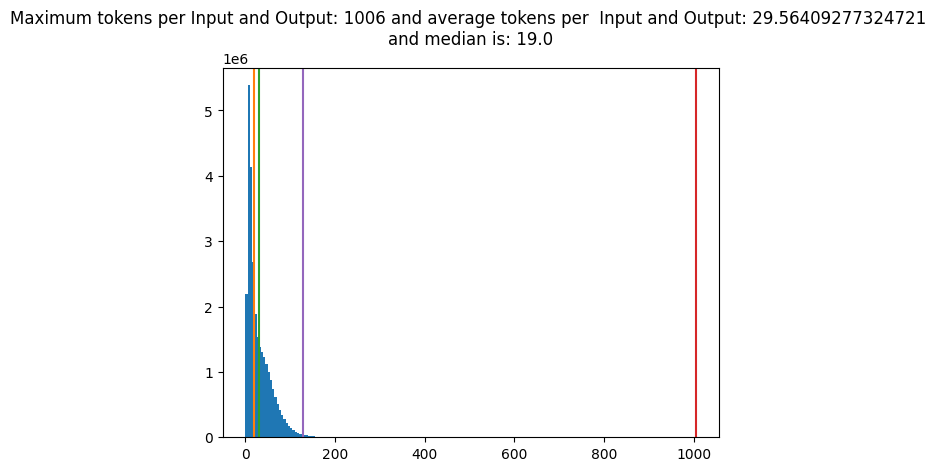

In [14]:
# ------------------------------------------------------------
# Tokenization
# ------------------------------------------------------------
# Purpose: Prepare subword tokenization and vocabulary.

plt.hist(token_lengths_df, np.linspace(0, 500, 101))
plt.ylim(plt.ylim())

median_length = token_lengths_df.median()[0]
plt.plot([median_length, median_length], plt.ylim())

avg_length = token_lengths_df.mean()[0]
plt.plot([avg_length, avg_length], plt.ylim())

max_length = token_lengths_df.max()[0]
plt.plot([max_length, max_length], plt.ylim())
plt.plot([128, 128], plt.ylim())

plt.title(f'Maximum tokens per Input and Output: {max_length} and average tokens per  Input and Output: {avg_length} \nand median is: {median_length}')
plt.show()

# **<center>3. Set up a data pipeline</center>**
___

## **3.1 Dataset splitting**

In [15]:
# ------------------------------------------------------------
# Processing
# ------------------------------------------------------------
# Purpose: Execute intermediate transformation steps.

train_dataset, val_dataset = train_test_split(input_output_dataset, test_size=0.30, random_state=123, shuffle=True)
val_dataset, test_dataset = train_test_split(val_dataset, test_size=0.20, random_state=123, shuffle=True)

In [16]:
# ------------------------------------------------------------
# Processing
# ------------------------------------------------------------
# Purpose: Execute intermediate transformation steps.

test_dataset.to_csv('test_dataset')

In [17]:
# ------------------------------------------------------------
# Processing
# ------------------------------------------------------------
# Purpose: Execute intermediate transformation steps.

print(f'Percentage of train_dataset:  {(len(train_dataset)/len(input_output_dataset)):.2f}')
print(f'Percentage of val_dataset:  {(len(val_dataset)/len(input_output_dataset)):.2f}')
print(f'Percentage of test_dataset:  {(len(test_dataset)/len(input_output_dataset)):.2f}')

Percentage of train_dataset:  0.70
Percentage of val_dataset:  0.24
Percentage of test_dataset:  0.06


## **3.2 Dataset & DataLoader**

In [18]:
# ------------------------------------------------------------
# Processing
# ------------------------------------------------------------
# Purpose: Execute intermediate transformation steps.

class UbuntuDataset(Dataset):
    def __init__(self, df):
        super().__init__()
        self.input = df.to_numpy()[:, 0]
        self.output = df.to_numpy()[:, 1]

    def __len__(self):
        return len(self.input)

    def __getitem__(self, idx):
        return (self.input[idx], self.output[idx])
        

In [20]:
# ------------------------------------------------------------
# Processing
# ------------------------------------------------------------
# Purpose: Execute intermediate transformation steps.

max_len = 128        # Maximum sequence length

In [21]:
# ------------------------------------------------------------
# Processing
# ------------------------------------------------------------
# Purpose: Execute intermediate transformation steps.

def pad_sequence(batch):
    inp_seqs = [torch.tensor(inp[:max_len]) for inp, out in batch]
    out_seqs = [torch.tensor(out[:max_len]) for inp, out in batch]

    padded_inp_seqs = torch.nn.utils.rnn.pad_sequence(inp_seqs, batch_first=True, padding_value=3)
    padded_out_seqs = torch.nn.utils.rnn.pad_sequence(out_seqs, batch_first=True, padding_value=3)
    return padded_inp_seqs, padded_out_seqs

In [22]:
# ------------------------------------------------------------
# Data Loading
# ------------------------------------------------------------
# Purpose: Load cleaned dialogue data from Part 1.

batch_size = 32
class Dataloaders:
    def __init__(self, dataset):
        self.dataset = UbuntuDataset(dataset)
        self.loader = torch.utils.data.DataLoader(self.dataset, batch_size=batch_size, shuffle=True, collate_fn=pad_sequence)

In [23]:
# ------------------------------------------------------------
# Data Loading
# ------------------------------------------------------------
# Purpose: Load cleaned dialogue data from Part 1.

train_dataloader = Dataloaders(train_dataset)
val_dataloader = Dataloaders(val_dataset)
test_dataloader = Dataloaders(test_dataset)

## **3.3 Data Preparing**

In [24]:
# ------------------------------------------------------------
# Processing
# ------------------------------------------------------------
# Purpose: Execute intermediate transformation steps.

# Model Essential Hyperparameters
# We reduce the model complexity to half of that in the Attention is All You Need paper by dividing all parameters by 2.
vocab_size = 10000     # Size of vocabulary
d_model = 256          # Embedding dimension = 512 in the original paper
nhead = 4              # Number of attention heads = 8 in the original paper
num_layers = 3 # equals 6 in the original paper
num_layers = 3 # equals 6 in the original paper
d_ff = 1024            # equals 2048 in the original paper
dropout = 0.1

In [25]:
# ------------------------------------------------------------
# Processing
# ------------------------------------------------------------
# Purpose: Execute intermediate transformation steps.

def create_masks(encoder_input, decoder_input, label, PAD):
    
    def subsequent_mask(size):
        mask = torch.triu(torch.ones(size, size)).transpose(0, 1).type(dtype=torch.uint8)
        return mask.unsqueeze(0)
    
    encoder_input_mask = (encoder_input!=PAD).to(device)
    encoder_input_mask = encoder_input_mask.unsqueeze(1).unsqueeze(1)         # (batch_size, 1, 1, seq_len)
     
    decoder_input_mask = (decoder_input!=PAD).to(device)
    decoder_input_mask = decoder_input_mask.unsqueeze(1)  # (batch_size, 1, seq_len)
    decoder_input_mask = decoder_input_mask & subsequent_mask(decoder_input.size(-1)).type_as(decoder_input_mask.data) 
    decoder_input_mask = decoder_input_mask.unsqueeze(1) # (batch_size, 1, seq_len, seq_len)
    label_mask = (label!=PAD).to(device)            # (batch_size, seq_len)
    
    return encoder_input_mask, decoder_input_mask, label_mask

In [26]:
# ------------------------------------------------------------
# Data Loading
# ------------------------------------------------------------
# Purpose: Load cleaned dialogue data from Part 1.

x, y = next(iter(train_dataloader.loader))

In [27]:
# ------------------------------------------------------------
# Processing
# ------------------------------------------------------------
# Purpose: Execute intermediate transformation steps.

encoder_input_mask, decoder_input_mask, label_mask = create_masks(x, y[:, :-1], y[:, 1:], PAD=3)

In [28]:
# ------------------------------------------------------------
# Processing
# ------------------------------------------------------------
# Purpose: Execute intermediate transformation steps.

encoder_input_mask[10,0,0, 50], x[10, 50]

(tensor(True, device='cuda:0'), tensor(12))

In [29]:
# ------------------------------------------------------------
# Processing
# ------------------------------------------------------------
# Purpose: Execute intermediate transformation steps.

decoder_input_mask[10,0,0, 20], y[:, :-1][10, 20]

(tensor(False, device='cuda:0'), tensor(3))

In [30]:
# ------------------------------------------------------------
# Processing
# ------------------------------------------------------------
# Purpose: Execute intermediate transformation steps.

label_mask[10, 20], y[:, 1:][10, 20]

(tensor(False, device='cuda:0'), tensor(3))

# **<center>4. Building a Transformer Architecture from Scratch</center>**

- Neural sequence transduction models, like the Conversational AI System we are developing, typically utilize an encoder-decoder structure.
- The encoder maps an input sequence of symbol representations $(x_1, ..., x_n)$ to a sequence of continuous representations $z = (z_1, ..., z_n)$. Given $z$, the decoder then generates an output sequence $(y1, ..., y_m)$ of symbols one element at a time. At each step the model is auto-regressive, consuming the previously generated symbols as additional input when generating the next.
- The Transformer follows this overall architecture using stacked self-attention and point-wise, fully connected layers for both the encoder and decoder.

- **The following figure shows a schematic of the Transformer architecture, and we will proceed to apply and illustrate each component of the architecture in detail, individually.**

![picture](https://github.com/arminnorouzi/machine_learning_course_UofA_MECE610/blob/main/L07_Generative_AI/figures/transformers.png?raw=true) **Source:** [Image Captioning with an End-to-End Transformer Network
](https://python.plainenglish.io/image-captioning-with-an-end-to-end-transformer-network-8f39e1438cd4)

### **4.1. The embedding and positional encoding layer**

- Given a sequence of tokens, both the `input tokens` and `target tokens` have to be converted to vectors using a `InputEmbeddings` layer.

- Since the model contains no recurrence and no convolution, in order for the model to make use of the order of the sequence, we must inject some information about the relative or absolute position of the tokens in the sequence.
- It needs some way to identify word order, otherwise it would see the input sequence as `a bag of words` instance, `how are you`, `how you are`, `you how are`, and so on, are indistinguishable.
- To this end, Transformer add `"positional encodings"` to the input embeddings at the bottoms of the encoder and decoder stacks. The positional encodings have the same dimension $d_{model}$ as the embeddings, so that the two can be summed. 
- It uses a set of sines and cosines at different frequencies (across the sequence). By definition nearby elements will have similar position encodings.
- **The original paper uses the following formula for calculating the positional encoding:**

$$\Large{PE_{(pos, 2i)} = \sin(pos / 10000^{2i / d_{model}})} $$
$$\Large{PE_{(pos, 2i+1)} = \cos(pos / 10000^{2i / d_{model}})} $$

- $pos$ is the token position.
- $k$ refers to each of the different dimensions in the positional encodings, with $i$ equal to $k//2$.
- $d_{model}$  is the dimension of the word embedding and positional encoding.

**Note:**  If you just hard code the positions in, say by adding `a matrix of 1's or whole numbers` to the word embedding, `the semantic meaning is distorted`. Conversely, the values of the sine and cosine equations are small enough `(between -1 and 1)` that when you add the positional encoding to a word embedding, the word embedding is not significantly distorted, and is instead enriched with positional information. 

**Note**: Similar to the original paper, the embeddings are scaled by multiplication with $\sqrt{d_{\text{model}}}$ to improve training dynamics.

In [31]:
# ------------------------------------------------------------
# Model Architecture
# ------------------------------------------------------------
# Purpose: Define Transformer encoder-decoder architecture.

class Embeddings(nn.Module):
    """
    Implements embeddings of the words and adds their positional encodings. 
    """
    def __init__(self, vocab_size, d_model, max_len = max_len):
        super(Embeddings, self).__init__()
        self.d_model = d_model
        self.dropout = nn.Dropout(0.1)
        self.embed = nn.Embedding(vocab_size, d_model)
        self.pe = self.create_positinal_encoding(max_len, self.d_model)
        self.dropout = nn.Dropout(0.1)
        
    def create_positinal_encoding(self, max_len, d_model):
        pe = torch.zeros(max_len, d_model).to(device)
        for pos in range(max_len):   # for each position of the word
            for i in range(0, d_model, 2):   # for each dimension of the each position
                pe[pos, i] = math.sin(pos / (10000 ** ((2 * i)/d_model)))
                pe[pos, i + 1] = math.cos(pos / (10000 ** ((2 * (i + 1))/d_model)))
        pe = pe.unsqueeze(0)   # include the batch size
        return pe
        
    def forward(self, encoded_words):
        embedding = self.embed(encoded_words) * math.sqrt(self.d_model)
        embedding += self.pe[:, :embedding.size(1)]   # pe will automatically be expanded with the same batch size as encoded_words
        embedding = self.dropout(embedding)
        return embedding

### **4.2. Multi-head self-attention**

**Before coding the MultiHeadAttention class, let’s clarify some potential confusion:**
- reshape and view both change a tensor’s shape, but view requires a contiguous tensor, while reshape can handle non-contiguous tensors by creating a copy if needed.
- transpose and permute are similar but not the same—transpose swaps only two dimensions, while permute can reorder all dimensions in any specified order.

In [32]:
# ------------------------------------------------------------
# Model Architecture
# ------------------------------------------------------------
# Purpose: Define Transformer encoder-decoder architecture.

class MultiHeadAttention(nn.Module):
    
    def __init__(self, heads, d_model):
        
        super(MultiHeadAttention, self).__init__()
        assert d_model % heads == 0
        self.d_k = d_model // heads
        self.heads = heads
        self.dropout = nn.Dropout(0.1)
        self.query = nn.Linear(d_model, d_model)
        self.key = nn.Linear(d_model, d_model)
        self.value = nn.Linear(d_model, d_model)
        self.concat = nn.Linear(d_model, d_model)
        
    def forward(self, query, key, value, mask):
        """
        query, key, value of shape: (batch_size, seq_len, d_model)
        mask of shape: (batch_size, 1, 1, seq_len)
        """
        # (batch_size, seq_len, d_model)
        query = self.query(query)
        key = self.key(key)        
        value = self.value(value)   
        
        # (batch_size, seq_len, d_model) --> (batch_size, seq_len, h, d_k) --> (batch_size, h, seq_len, d_k)
        query = query.view(query.shape[0], -1, self.heads, self.d_k).permute(0, 2, 1, 3)   
        key = key.view(key.shape[0], -1, self.heads, self.d_k).permute(0, 2, 1, 3)  
        value = value.view(value.shape[0], -1, self.heads, self.d_k).permute(0, 2, 1, 3)  
        
        # (batch_size, h, seq_len, d_k) matmul (batch_size, h, d_k, seq_len) --> (batch_size, h, seq_len, seq_len)
        scores = torch.matmul(query, key.permute(0,1,3,2)) / math.sqrt(query.size(-1))
        scores = scores.masked_fill(mask == 0, -1e9)    # (batch_size, h, seq_len, seq_len)
        weights = F.softmax(scores, dim = -1)           # (batch_size, h, seq_len, seq_len)
        weights = self.dropout(weights)
        # (batch_size, h, seq_len, seq_len) matmul (batch_size, h, seq_len, d_k) --> (batch_size, h, seq_len, d_k)
        context = torch.matmul(weights, value)
        # (batch_size, h, seq_len, d_k) --> (batch_size, seq_len, h, d_k) --> (batch_size, seq_len, h * d_k)
        context = context.permute(0,2,1,3).contiguous().view(context.shape[0], -1, self.heads * self.d_k)
        # (batch_size, seq_len, h * d_k)
        interacted = self.concat(context)
        return interacted 

### **4.2. The feed forward network**

- The transformer also includes point-wise feed-forward network in both the encoder and decoder, which is applied to each position separately and identically.
<center>$\text{FFN}(x) = \max(0, xW_1 + b_1)W_2 + b_2 \tag{2}$</center>

- While the linear transformations are the same across different positions, they use different parameters from layer to layer. Another way of describing this is as `two convolutions` with a `kernel size of 1`. `The dimensionality of input and output is` $d_{\text{model}} = 256$, and `the inner-layer has dimensionality` $d_{\text{ff}} = 1024$.

In [34]:
# ------------------------------------------------------------
# Model Architecture
# ------------------------------------------------------------
# Purpose: Define Transformer encoder-decoder architecture.

class FeedForward(nn.Module):

    def __init__(self, d_model, middle_dim = d_ff, dropout=dropout):
        super(FeedForward, self).__init__()
        
        self.fc1 = nn.Linear(d_model, middle_dim)
        self.fc2 = nn.Linear(middle_dim, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out = F.relu(self.fc1(x))
        out = self.fc2(self.dropout(out))
        return out

### **4.3. Transformer Encoder**

In [36]:
# ------------------------------------------------------------
# Model Architecture
# ------------------------------------------------------------
# Purpose: Define Transformer encoder-decoder architecture.

class EncoderLayer(nn.Module):

    def __init__(self, d_model, heads):
        super().__init__()
        self.layernorm = nn.LayerNorm(d_model)
        self.self_multihead = MultiHeadAttention(heads, d_model)
        self.feed_forward = FeedForward(d_model)
        self.dropout = nn.Dropout(0.1)

    def forward(self, embeddings, mask):
        interacted = self.dropout(self.self_multihead(embeddings, embeddings, embeddings, mask))
        interacted = self.layernorm(interacted + embeddings)
        feed_forward_out = self.dropout(self.feed_forward(interacted))
        encoded = self.layernorm(feed_forward_out + interacted)
        return encoded


### **4.4. Transformer Decoder**

In [37]:
# ------------------------------------------------------------
# Model Architecture
# ------------------------------------------------------------
# Purpose: Define Transformer encoder-decoder architecture.

class DecoderLayer(nn.Module):
    
    def __init__(self, d_model, heads):
        super(DecoderLayer, self).__init__()
        self.layernorm = nn.LayerNorm(d_model)
        self.self_multihead = MultiHeadAttention(heads, d_model)
        self.src_multihead = MultiHeadAttention(heads, d_model)
        self.feed_forward = FeedForward(d_model)
        self.dropout = nn.Dropout(0.1)
        
    def forward(self, embeddings, encoded, src_mask, target_mask):
        query = self.dropout(self.self_multihead(embeddings, embeddings, embeddings, target_mask))
        query = self.layernorm(query + embeddings)
        interacted = self.dropout(self.src_multihead(query, encoded, encoded, src_mask))
        interacted = self.layernorm(interacted + query)
        feed_forward_out = self.dropout(self.feed_forward(interacted))
        decoded = self.layernorm(feed_forward_out + interacted)
        return decoded

### **4.5. Transformer**

In [38]:
# ------------------------------------------------------------
# Model Architecture
# ------------------------------------------------------------
# Purpose: Define Transformer encoder-decoder architecture.

class Transformer(nn.Module):
    
    def __init__(self, d_model, heads, num_layers, vocab_size):
        super(Transformer, self).__init__()
        
        self.d_model = d_model
        self.vocab_size = vocab_size
        self.embed = Embeddings(self.vocab_size, d_model)
        self.encoder = nn.ModuleList([EncoderLayer(d_model, heads) for _ in range(num_layers)])
        self.decoder = nn.ModuleList([DecoderLayer(d_model, heads) for _ in range(num_layers)])
        self.logit = nn.Linear(d_model, self.vocab_size)
        
    def encode(self, src_words, src_mask):
        src_embeddings = self.embed(src_words)
        for layer in self.encoder:
            src_embeddings = layer(src_embeddings, src_mask)
        return src_embeddings
    
    def decode(self, target_words, target_mask, src_embeddings, src_mask):
        tgt_embeddings = self.embed(target_words)
        for layer in self.decoder:
            tgt_embeddings = layer(tgt_embeddings, src_embeddings, src_mask, target_mask)
        return tgt_embeddings
        
    def forward(self, src_words, src_mask, target_words, target_mask):
        encoded = self.encode(src_words, src_mask)
        decoded = self.decode(target_words, target_mask, encoded, src_mask)
        out = F.log_softmax(self.logit(decoded), dim = 2)
        return out

### **4.6. Optimization and Loss Handling**

In [39]:
# ------------------------------------------------------------
# Optimization Setup
# ------------------------------------------------------------
# Purpose: Configure optimizer and learning rate schedule.

class AdamWarmup:
    
    def __init__(self, model_size, warmup_steps, optimizer):
        
        self.model_size = model_size
        self.warmup_steps = warmup_steps
        self.optimizer = optimizer
        self.current_step = 0
        self.lr = 0
        
    def get_lr(self):
        return self.model_size ** (-0.5) * min(self.current_step ** (-0.5), self.current_step * self.warmup_steps ** (-1.5))
        
    def step(self):
        # Increment the number of steps each time we call the step function
        self.current_step += 1
        lr = self.get_lr()
        for param_group in self.optimizer.param_groups:
            param_group['lr'] = lr
        # update the learning rate
        self.lr = lr
        self.optimizer.step()   

In [40]:
# ------------------------------------------------------------
# Model Architecture
# ------------------------------------------------------------
# Purpose: Define Transformer encoder-decoder architecture.

class LossWithLS(nn.Module):

    def __init__(self, size, smooth):
        super(LossWithLS, self).__init__()
        self.criterion = nn.KLDivLoss(size_average=False, reduce=False)
        self.confidence = 1.0 - smooth
        self.smooth = smooth
        self.size = size
        
    def forward(self, prediction, target, mask):
        """
        prediction of shape: (batch_size, seq_len, vocab_size)
        target and mask of shape: (batch_size, seq_len)
        """
        prediction = prediction.view(-1, prediction.size(-1))   # (batch_size * max_words, vocab_size)
        target = target.contiguous().view(-1)   # (batch_size * max_words)
        mask = mask.float()
        mask = mask.view(-1)       # (batch_size * max_words)
        labels = prediction.data.clone()
        labels.fill_(self.smooth / (self.size - 1))
        labels.scatter_(1, target.data.unsqueeze(1), self.confidence)
        loss = self.criterion(prediction, labels)    # (batch_size * seq_len, vocab_size)
        loss = (loss.sum(1) * mask).sum() / mask.sum()
        return loss

# **<center>5. Training</center>**

In [41]:
# ------------------------------------------------------------
# Optimization Setup
# ------------------------------------------------------------
# Purpose: Configure optimizer and learning rate schedule.

transformer = Transformer(d_model = d_model, heads = nhead, num_layers = num_layers, vocab_size = vocab_size)
transformer = transformer.to(device)
adam_optimizer = torch.optim.Adam(transformer.parameters(), lr=0, betas=(0.9, 0.98), eps=1e-9)
transformer_optimizer = AdamWarmup(model_size = d_model, warmup_steps = 4000, optimizer = adam_optimizer)
criterion = LossWithLS(vocab_size, 0.1)

/usr/local/lib/python3.10/dist-packages/torch/nn/_reduction.py:42: UserWarning: size_average and reduce args will be deprecated, please use reduction='none' instead.
  warnings.warn(warning.format(ret))


In [43]:
# ------------------------------------------------------------
# Data Loading
# ------------------------------------------------------------
# Purpose: Load cleaned dialogue data from Part 1.

def train(train_loader, transformer, criterion, epoch):
    
    transformer.train()
    sum_loss = 0
    count = 0

    for i, (encoder_input, decoder_data) in enumerate(train_loader):
        
        samples = encoder_input.shape[0]

        # Move to device
        encoder_input = encoder_input.to(device)
        decoder_data = decoder_data.to(device)

        # Prepare Target Data
        decoder_input = decoder_data[:, :-1]
        label = decoder_data[:, 1:]

        # Create mask and add dimensions
        encoder_input_mask, decoder_input_mask, label_mask = create_masks(encoder_input, decoder_input, label, PAD=3)

        # Get the transformer outputs
        out = transformer(encoder_input, encoder_input_mask, decoder_input, decoder_input_mask)
        

        # Compute the loss
        loss = criterion(out, label, label_mask)
        
        # Backprop
        transformer_optimizer.optimizer.zero_grad()
        loss.backward()
        transformer_optimizer.step()
        
        sum_loss += loss.item() * samples
        count += samples
        
        if (i+1) % 10000 == 0:
            print("Epoch [{}][{}/{}]\tLoss: {:.3f}".format(epoch+1, i+1, len(train_loader), sum_loss/count))

        if (i+1) % 10000 == 0:
            
            state = {'batch': i+1, 'transformer': transformer, 'transformer_optimizer': transformer_optimizer}
            torch.save(state, 'checkpoint_' + str(i+1) + '.pth.tar')
            print('model_saved')

        if (i+1) >= 2*(10**5):
            break
            
    avg_loss = sum_loss / count
    print(f"Training Loss: {avg_loss:.3f}")
    return transformer, avg_loss
    
for epoch in range(1):
    
    transformer_model, avg_loss = train(train_dataloader.loader, transformer, criterion, epoch)

Epoch [1][10000/314225]	Loss: 4.707
model_saved
Epoch [1][20000/314225]	Loss: 4.560
model_saved
Epoch [1][30000/314225]	Loss: 4.486
model_saved
Epoch [1][40000/314225]	Loss: 4.438
model_saved
Epoch [1][50000/314225]	Loss: 4.403
model_saved
Epoch [1][60000/314225]	Loss: 4.377
model_saved
Epoch [1][70000/314225]	Loss: 4.356
model_saved
Epoch [1][80000/314225]	Loss: 4.339
model_saved
Epoch [1][90000/314225]	Loss: 4.324
model_saved
Epoch [1][100000/314225]	Loss: 4.311
model_saved
Epoch [1][110000/314225]	Loss: 4.300
model_saved
Epoch [1][120000/314225]	Loss: 4.290
model_saved
Epoch [1][130000/314225]	Loss: 4.281
model_saved
Epoch [1][140000/314225]	Loss: 4.273
model_saved
Epoch [1][150000/314225]	Loss: 4.266
model_saved
Epoch [1][160000/314225]	Loss: 4.259
model_saved
Epoch [1][170000/314225]	Loss: 4.252
model_saved
Epoch [1][180000/314225]	Loss: 4.246
model_saved
Epoch [1][190000/314225]	Loss: 4.241
model_saved
Epoch [1][200000/314225]	Loss: 4.236
model_saved
Training Loss: 4.236


# **<center>6. Validation</center>**

In [46]:
# ------------------------------------------------------------
# Data Loading
# ------------------------------------------------------------
# Purpose: Load cleaned dialogue data from Part 1.

def validate(val_loader, transformer, criterion):
    transformer.eval()  # Set model to evaluation mode
    sum_loss = 0
    count = 0

    with torch.no_grad():  # Disable gradient computation
        for i, (encoder_input, decoder_data) in enumerate(val_loader):
            samples = encoder_input.shape[0]

            # Move to device
            encoder_input = encoder_input.to(device)
            decoder_data = decoder_data.to(device)

            # Prepare Target Data
            decoder_input = decoder_data[:, :-1]
            label = decoder_data[:, 1:]

            # Create mask and add dimensions
          
            encoder_input_mask, decoder_input_mask, label_mask = create_masks(encoder_input, decoder_input, label, PAD=3)

            # Get the transformer outputs
            out = transformer(encoder_input, encoder_input_mask, decoder_input, decoder_input_mask)

            # Compute the loss
            loss = criterion(out, label, label_mask)

            sum_loss += loss.item() * samples
            count += samples

            if (i+1) % 10000 == 0:  
                print(
                    "Validation Step [{}/{}]\tLoss: {:.3f}".format(i + 1, len(val_loader), sum_loss / count)
                )

            if (i+1) >= ((10**5)*0.2):
                break
            
    avg_loss = sum_loss / count
    print(f"Validation Loss: {avg_loss:.3f}")
    return avg_loss

In [47]:
# ------------------------------------------------------------
# Data Loading
# ------------------------------------------------------------
# Purpose: Load cleaned dialogue data from Part 1.

val_avg_loss = validate(val_dataloader.loader, transformer_model, criterion)

Validation Step [10000/107734]	Loss: 4.027
Validation Step [20000/107734]	Loss: 4.027
Validation Loss: 4.027


# **<center>7. Evaluation</center>**

In [48]:
# ------------------------------------------------------------
# Processing
# ------------------------------------------------------------
# Purpose: Execute intermediate transformation steps.

def reply_to_query(model, x):
    """Generate a response to the input query without using any ground-truth responses for guidance."""
    with torch.no_grad():
        batch_size = x.size(0)
        y = torch.tensor([[BOS]*batch_size]).view(batch_size, 1).to(device)
        x_pad_mask = (x == PAD).view(x.size(0), 1, 1, x.size(-1)).to(device)
        memory = model.encode(x, x_pad_mask)
        for i in range(max_len):
            y_pad_mask = (y == PAD).view(y.size(0), 1, 1, y.size(-1)).to(device)

            decoded = model.decode(y, y_pad_mask, memory, x_pad_mask)

            logits = transformer.logit(decoded)
            last_output = logits.argmax(-1)[:, -1]
            last_output = last_output.view(batch_size, 1)
            y = torch.cat((y, last_output), 1).to(device)
    return y

In [56]:
# ------------------------------------------------------------
# Data Loading
# ------------------------------------------------------------
# Purpose: Load cleaned dialogue data from Part 1.

def remove_pad(sent):
    '''truncate the sentence if BOS is in it,
     otherwise simply remove the padding tokens at the end'''
    if sent.count(EOS)>0:
      sent = sent[0:sent.index(EOS)+1]
    while sent and sent[-1] == PAD:
            sent = sent[:-1]
    return sent

def decode_sentence(detokenizer_ids, sentence_ids):
    'convert a tokenized sentence (a list of numbers) to a literal string'
    if not isinstance(sentence_ids, list):
        sentence_ids = sentence_ids.tolist()
    sentence_ids = remove_pad(sentence_ids)
    return detokenizer_ids(sentence_ids).replace("<sep>", "")\
           .replace("<pad>", "").strip().replace(" .", ".")

def evaluate(model, dataloader, num_batch=None):
    'evaluate the model, and compute the BLEU score'
    model.eval()
    refs, cans, bleus = [], [], []
    with torch.no_grad():
        
        for idx, (encoder_input, decoder_data) in enumerate(dataloader):
            
            # Move to device
            encoder_input = encoder_input.to(device)
            decoder_data = decoder_data.to(device)
            
            # Prepare Target Data
            decoder_input = decoder_data[:, :-1]
            label = decoder_data[:, 1:]
            # Create mask and add dimensions
            encoder_input_mask, decoder_input_mask, label_mask = create_masks(encoder_input, decoder_input, label, PAD=3)

            reply = reply_to_query(model, encoder_input)
            label = label.view(encoder_input.size(0), -1)
            refs = refs + [decode_sentence(detokenizer_ids, label[i]) for i in range(len(encoder_input))]
            cans = cans + [decode_sentence(detokenizer_ids, reply[i]) for i in range(len(encoder_input))] 
            if num_batch and idx>=num_batch:
                break
        print(min([len(x) for x in refs]))
        bleus.append(sacrebleu.corpus_bleu(cans, [refs]).score)
        # print some examples
        for i in range(3):
            print(f'src:  {decode_sentence(detokenizer_ids, encoder_input[i])}')
            print(f'trg:  {decode_sentence(detokenizer_ids, label[i])}')
            print(f'pred: {decode_sentence(detokenizer_ids, reply[i])}')
        return bleus

In [57]:
# ------------------------------------------------------------
# Processing
# ------------------------------------------------------------
# Purpose: Execute intermediate transformation steps.

UNK, BOS, EOS, PAD, SEP = 0, 1, 2, 3, 4

In [58]:
# ------------------------------------------------------------
# Data Loading
# ------------------------------------------------------------
# Purpose: Load cleaned dialogue data from Part 1.

bleus = evaluate(transformer_model, test_dataloader.loader, num_batch=20)

1
src:  hi
trg:  hopefully a quick q
pred: please dont
src:  packagesubuntuati packagersh 311 sh c usrsbinsynaptic set selections non interactive hide main window tmpfilemzwyvj not found generating package ubuntu710
trg:  unable to install dpkg dev and build essential please manually install and try again
pred: please dont
src:  any way i can reset it to gdm or kdm starts on its own that is why then you need to use something like gdm or kdm and have that start when you boot no straight to terminal i recently installed kubuntu when you start ubuntu do you get a login screen using gdm
trg:  is gdm installed
pred: please dont


In [62]:
# ------------------------------------------------------------
# Processing
# ------------------------------------------------------------
# Purpose: Execute intermediate transformation steps.

print(f'test_bleu: {np.mean(bleus)}')

test_bleu: 1.034


# **<center>7. ChatBot</center>**

In [63]:
# ------------------------------------------------------------
# Tokenization
# ------------------------------------------------------------
# Purpose: Prepare subword tokenization and vocabulary.

def chatbot(transformer, query, query_mask, max_len):
    """
    Performs Greedy Decoding with a batch size of 1
    """
    transformer.eval()
    start_token = BOS
    encoded = transformer.encode(query, query_mask)
    words = torch.LongTensor([[start_token]]).to(device)
    
    for step in range(max_len - 1):
        size = words.shape[1]
        target_mask = torch.triu(torch.ones(size, size)).transpose(0, 1).type(dtype=torch.uint8)
        target_mask = target_mask.to(device).unsqueeze(0).unsqueeze(0)
        decoded = transformer.decode(words, target_mask, encoded, question_mask)
        predictions = transformer.logit(decoded[:, -1])
        _, next_word = torch.max(predictions, dim = 1)
        next_word = next_word.item()
        if next_word == EOS:
            break
        words = torch.cat([words, torch.LongTensor([[next_word]]).to(device)], dim = 1)   # (1,step+2)
        
    # Construct Sentence
    if words.dim() == 2:
        words = words.squeeze(0)
        words = words.tolist()
        
    sen_idx = [w for w in words if w not in {BOS, PAD, SEP}]
    sentence = ' '.join([detokenizer_ids([sen_idx[k]]) for k in range(len(sen_idx))])
    
    return sentence

In [66]:
# ------------------------------------------------------------
# Processing
# ------------------------------------------------------------
# Purpose: Execute intermediate transformation steps.

def clean_text(text):

    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)

    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # Replace underscores and hyphens with spaces
    text = re.sub(r'[_-]', ' ', text)

    # Remove non-alphanumeric characters (preserve whitespace)
    text = re.sub(r'[^a-zA-Z\s\d]', '', text)

    # Convert multiple whitespace characters to a single space
    text = re.sub(r'\s+', ' ', text)

    # Convert text to lowercase
    text = text.lower()

    # Reduce elongated words (e.g., "chooooose" to "choose")
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)

    return text

### The following demonstrates a real-world example of running the model as a chatbot in real time.

These are examples for the running:

- Question:  How do I set up a web server using Nginx?
- Question:  “Explain the difference between apt and apt-get.”
- Question:  Explain the difference between apt and apt-get
- Question:  How do I remove a package and all its dependencies?

In [72]:
# ------------------------------------------------------------
# Tokenization
# ------------------------------------------------------------
# Purpose: Prepare subword tokenization and vocabulary.

while(1):
    question = input("Question: ") 
    if question == 'quit':
        break
    max_len = input("Maximum Reply Length: ")
    enc_qus = tokenizer_ids(clean_text(question))
    question = torch.LongTensor(enc_qus).to(device).unsqueeze(0)
    question_mask = (question!=PAD).to(device).unsqueeze(1).unsqueeze(1)  
    sentence = chatbot(transformer, question, question_mask, int(max_len))
    print(sentence)

Question:  How do I set up a web server using Nginx?
Maximum Reply Length:  30


i dont know how to set up a server


Question:  “Explain the difference between apt and apt-get.”
Maximum Reply Length:  30


apt get is a good idea to get


Question:  Explain the difference between apt and apt-get
Maximum Reply Length:  100


apt get is a good idea to get


Question:  How do I remove a package and all its dependencies?
Maximum Reply Length:  30


apt get remove purge


Question:  quit


# **<center>THANKS</center>**